In [6]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [40]:
from pathlib import Path

# Project Root
PROJECT_ROOT = Path("..")

# Data Folder
DATA_DIR = PROJECT_ROOT / "data"

# Image Folder
IMAGE_DIR = DATA_DIR / "eye_image"

# Clinical Dataset
CLINICAL_PATH = DATA_DIR / "clinical" / "anemia.csv"

# Geo Dataset
GEO_PATH = DATA_DIR / "geo" / "datafile.csv"

In [55]:
print(IMAGE_DIR)
print(IMAGE_DIR.exists())

..\data\eye_image
True


In [56]:
import os

print(os.listdir(IMAGE_DIR))

['Dataset anemia.docx', 'India', 'Italy']


In [41]:
print("=" * 50)
print("PROJECT ROOT :", PROJECT_ROOT.resolve())
print("=" * 50)

print("IMAGE DIR :", IMAGE_DIR)
print("CLINICAL :", CLINICAL_PATH)
print("GEO :", GEO_PATH)

print()

print("Image Folder Exists :", IMAGE_DIR.exists())
print("Clinical Exists :", CLINICAL_PATH.exists())
print("Geo Exists :", GEO_PATH.exists())

PROJECT ROOT : C:\Users\hp\Documents\Anemia_Fusion_Net_project
IMAGE DIR : ..\data\eye_image
CLINICAL : ..\data\clinical\anemia.csv
GEO : ..\data\geo\datafile.csv

Image Folder Exists : True
Clinical Exists : True
Geo Exists : True


In [42]:
clinical_df = pd.read_csv(CLINICAL_PATH)

print("Clinical Dataset Shape:", clinical_df.shape)

clinical_df.head()

Clinical Dataset Shape: (1421, 6)


,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [43]:
geo_df = pd.read_csv(GEO_PATH)

print("Geo Dataset Shape:", geo_df.shape)

geo_df.head()

Geo Dataset Shape: (706, 109)


,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ≥160 mm of Hg and/or Diastolic ≥100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,Nicobars,Andaman & Nicobar Islands,882,764,125,78.0,23.0,973,927,98.0,...,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5
1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,82.7,19.8,950,844,100.0,...,22.6,6.0,32.2,1.7,0.3,15.8,46.8,70.5,5.1,45.3
2,South Andaman,Andaman & Nicobar Islands,868,844,134,84.7,21.0,967,935,96.5,...,17.9,6.1,26.9,1.3,0.7,8.0,19.6,50.8,1.7,32.8
3,Srikakulam,Andhra Pradesh,874,780,100,60.0,20.7,1140,1163,95.0,...,14.4,5.5,22.9,1.0,0.2,3.8,7.1,21.3,0.6,28.3
4,Vizianagaram,Andhra Pradesh,902,853,134,56.0,20.6,1114,898,95.4,...,14.8,6.4,25.1,4.9,0.6,7.3,11.4,21.5,0.8,32.3


In [44]:
print("=" * 60)
print("Clinical Dataset Information")
print("=" * 60)

clinical_df.info()

Clinical Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


In [45]:
print("=" * 60)
print("Clinical Dataset Information")
print("=" * 60)

clinical_df.info()

Clinical Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


In [46]:
duplicates = clinical_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 887


In [47]:
clinical_df.describe(include="all")

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000


In [48]:
print(clinical_df.columns.tolist())

['Gender', 'Hemoglobin', 'MCH', 'MCHC', 'MCV', 'Result']


In [49]:
print("=" * 60)
print("Geo Dataset Information")
print("=" * 60)

geo_df.info()

Geo Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Columns: 109 entries, District Names to Men age 15 years and above who consume alcohol (%)
dtypes: float64(54), int64(4), object(51)
memory usage: 601.3+ KB


In [50]:
geo_df.isnull().sum()

District Names                                                                           0
State/UT                                                                                 0
Number of Households surveyed                                                            0
Number of Women age 15-49 years interviewed                                              0
Number of Men age 15-54 years interviewed                                                0
                                                                                        ..
Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%)    0
Women age 15 years and above who use any kind of tobacco (%)                             0
Men age 15 years and above who use any kind of tobacco (%)                               0
Women age 15 years and above who consume alcohol (%)                                     0
Men age 15 years and above who consume alcohol (%)                                       0

In [51]:
geo_df.describe(include="all")

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ≥160 mm of Hg and/or Diastolic ≥100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
count,706,706,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706,706.000000,...,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000,706.000000
unique,698,36,NaN,NaN,NaN,NaN,NaN,NaN,351,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Bilaspur,Uttar Pradesh,NaN,NaN,NaN,NaN,NaN,NaN,885,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,75,NaN,NaN,NaN,NaN,NaN,NaN,8,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,900.481586,1023.929178,143.975921,71.514448,26.367847,1020.640227,NaN,91.056516,...,16.264873,6.052550,24.774788,1.574363,0.657649,0.705949,11.622238,40.591926,2.922380,23.195184
std,NaN,NaN,69.320330,177.174124,31.967905,10.319860,5.297820,73.400047,NaN,9.392669,...,4.337494,2.572881,6.767158,2.774812,1.569643,1.468871,11.950115,14.087173,6.083796,13.373136
min,NaN,NaN,213.000000,216.000000,17.000000,45.400000,16.000000,755.000000,NaN,51.600000,...,5.300000,0.800000,10.000000,0.000000,0.000000,0.000000,0.100000,6.800000,0.000000,0.100000
25%,NaN,NaN,882.000000,911.000000,124.000000,64.400000,22.500000,969.000000,NaN,87.025000,...,13.200000,4.100000,19.800000,0.200000,0.000000,0.000000,4.100000,30.350000,0.300000,13.600000
50%,NaN,NaN,908.000000,1020.000000,145.000000,71.350000,25.400000,1013.000000,NaN,94.850000,...,16.300000,5.800000,24.400000,0.600000,0.200000,0.300000,7.700000,42.500000,0.500000,20.150000
75%,NaN,NaN,931.000000,1141.500000,164.000000,78.975000,29.500000,1065.750000,NaN,97.700000,...,18.875000,7.600000,29.000000,1.500000,0.500000,0.700000,14.800000,50.975000,1.700000,30.900000


In [52]:
from pathlib import Path

image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

image_paths = []

for ext in image_extensions:
    image_paths.extend(IMAGE_DIR.rglob(f"*{ext}"))

print(f"Total Images : {len(image_paths)}")

Total Images : 862


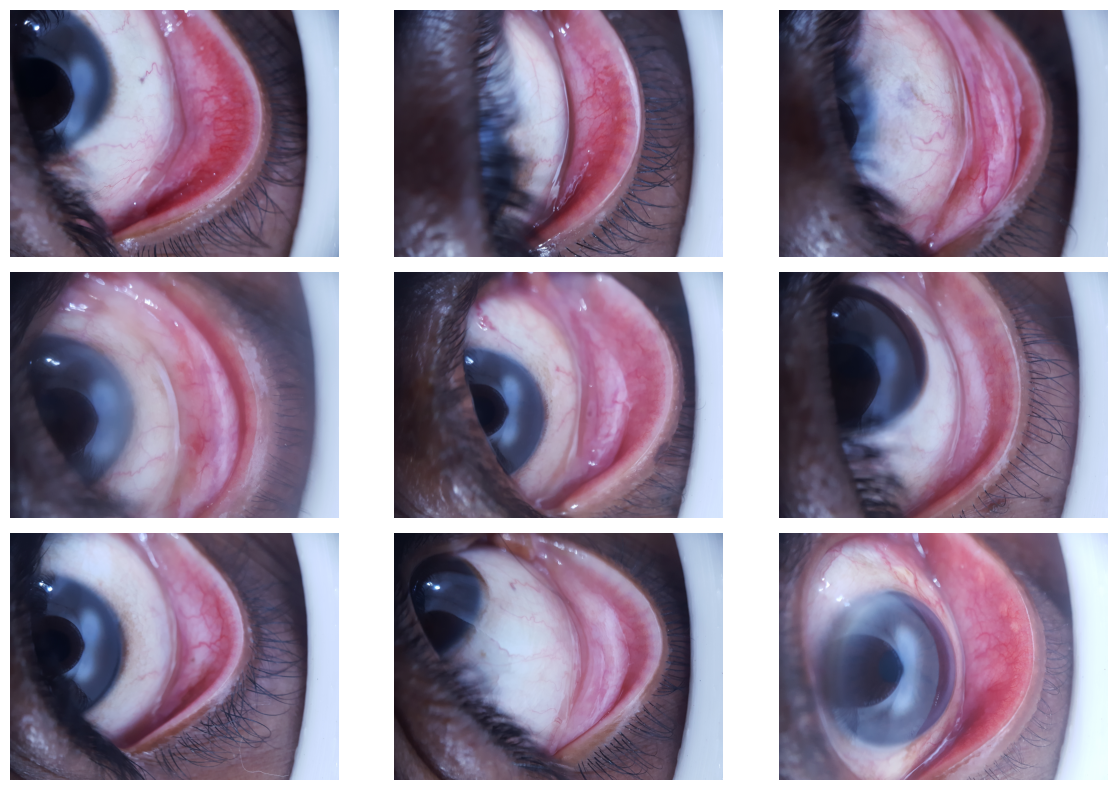

In [53]:
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

for i, img_path in enumerate(image_paths[:9]):
    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

print(os.listdir(PROJECT_ROOT / "data"))

['clinical', 'eye_image', 'geo']


In [ ]:
print(PROJECT_ROOT)
print(DATA_DIR)
print(IMAGE_DIR)
print((PROJECT_ROOT / "data").resolve())
print(IMAGE_DIR.resolve())

..
..\data
..\data\eye image
C:\Users\hp\Documents\Anemia_Fusion_Net_project\data
C:\Users\hp\Documents\Anemia_Fusion_Net_project\data\eye image


In [57]:
import os

print("India Folder:")
print(os.listdir(IMAGE_DIR / "India")[:20])

print("\nItaly Folder:")
print(os.listdir(IMAGE_DIR / "Italy")[:20])

India Folder:
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27']

Italy Folder:
['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116']


In [58]:
for root, dirs, files in os.walk(IMAGE_DIR):
    print(f"\n📁 {root}")
    print(f"Folders: {dirs}")
    print(f"Files: {files[:5]}")


📁 ..\data\eye_image
Folders: ['India', 'Italy']
Files: ['Dataset anemia.docx']

📁 ..\data\eye_image\India
Folders: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95']
Files: ['India.xlsx']

📁 ..\data\eye_image\India\1
Folders: []
Files: ['20200118_164733.jpg', '20200118_164733_forniceal.png', '20200118_164733_forniceal_palpebral.png', '20200118_164733_palpebral.png']

📁 ..\data\eye_image\India\10
Folders: []
Files: ['20200203_091841.jpg', '20200203_091841_forniceal.png', '20200203_091

In [59]:
for root, dirs, files in os.walk(IMAGE_DIR):
    if files:
        print(f"\nFolder: {root}")
        print("Sample Files:", files[:5])


Folder: ..\data\eye_image
Sample Files: ['Dataset anemia.docx']

Folder: ..\data\eye_image\India
Sample Files: ['India.xlsx']

Folder: ..\data\eye_image\India\1
Sample Files: ['20200118_164733.jpg', '20200118_164733_forniceal.png', '20200118_164733_forniceal_palpebral.png', '20200118_164733_palpebral.png']

Folder: ..\data\eye_image\India\10
Sample Files: ['20200203_091841.jpg', '20200203_091841_forniceal.png', '20200203_091841_forniceal_palpebral.png', '20200203_091841_palpebral.png']

Folder: ..\data\eye_image\India\11
Sample Files: ['20200203_094523.jpg', '20200203_094523_forniceal.png', '20200203_094523_forniceal_palpebral.png', '20200203_094523_palpebral.png']

Folder: ..\data\eye_image\India\12
Sample Files: ['20200203_103722.jpg', '20200203_103722_forniceal.png', '20200203_103722_forniceal_palpebral.png', '20200203_103722_palpebral.png']

Folder: ..\data\eye_image\India\13
Sample Files: ['20200203_190841.jpg', '20200203_190841_forniceal.png', '20200203_190841_forniceal_palpebra

In [60]:
from pathlib import Path

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".JPG",
    ".JPEG",
    ".PNG"
}

image_paths = []

for file in IMAGE_DIR.rglob("*"):
    if file.suffix in image_extensions:
        image_paths.append(file)

print("Total Images:", len(image_paths))

Total Images: 862


In [61]:
from pathlib import Path

india_images = list((IMAGE_DIR / "India").rglob("*"))
italy_images = list((IMAGE_DIR / "Italy").rglob("*"))

india_count = sum(
    1 for f in india_images
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
)

italy_count = sum(
    1 for f in italy_images
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
)

print(f"India Images : {india_count}")
print(f"Italy Images : {italy_count}")
print(f"Total Images : {india_count + italy_count}")

India Images : 382
Italy Images : 480
Total Images : 862


In [62]:
from pathlib import Path

india_images = list((IMAGE_DIR / "India").rglob("*"))
italy_images = list((IMAGE_DIR / "Italy").rglob("*"))

india_count = sum(
    1 for f in india_images
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
)

italy_count = sum(
    1 for f in italy_images
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
)

print(f"India Images : {india_count}")
print(f"Italy Images : {italy_count}")
print(f"Total Images : {india_count + italy_count}")

India Images : 382
Italy Images : 480
Total Images : 862


In [64]:
from PIL import Image

sizes = []
bad_images = []

for img_path in image_paths:
    try:
        with Image.open(img_path) as img:
            img.verify()   # Verify image integrity

        with Image.open(img_path) as img:
            sizes.append(img.size)

    except Exception as e:
        bad_images.append((img_path, str(e)))

print(f"Valid Images   : {len(sizes)}")
print(f"Corrupted Files: {len(bad_images)}")

Valid Images   : 675
Corrupted Files: 187


In [65]:
import cv2

bad_cv = []

for path, _ in bad_images:
    img = cv2.imread(str(path))

    if img is None:
        bad_cv.append(path)

print("Unreadable even with OpenCV:", len(bad_cv))


Unreadable even with OpenCV: 0


In [66]:
import cv2

sizes = []

for img_path in image_paths:
    img = cv2.imread(str(img_path))

    if img is not None:
        height, width = img.shape[:2]
        sizes.append((width, height))

print(f"Valid Images: {len(sizes)}")
print(f"Unique Image Sizes: {len(set(sizes))}")

from collections import Counter

print("\nTop 10 Image Sizes:")
print(Counter(sizes).most_common(10))

Valid Images: 862
Unique Image Sizes: 2

Top 10 Image Sizes:
[((800, 1067), 643), ((2988, 3984), 219)]


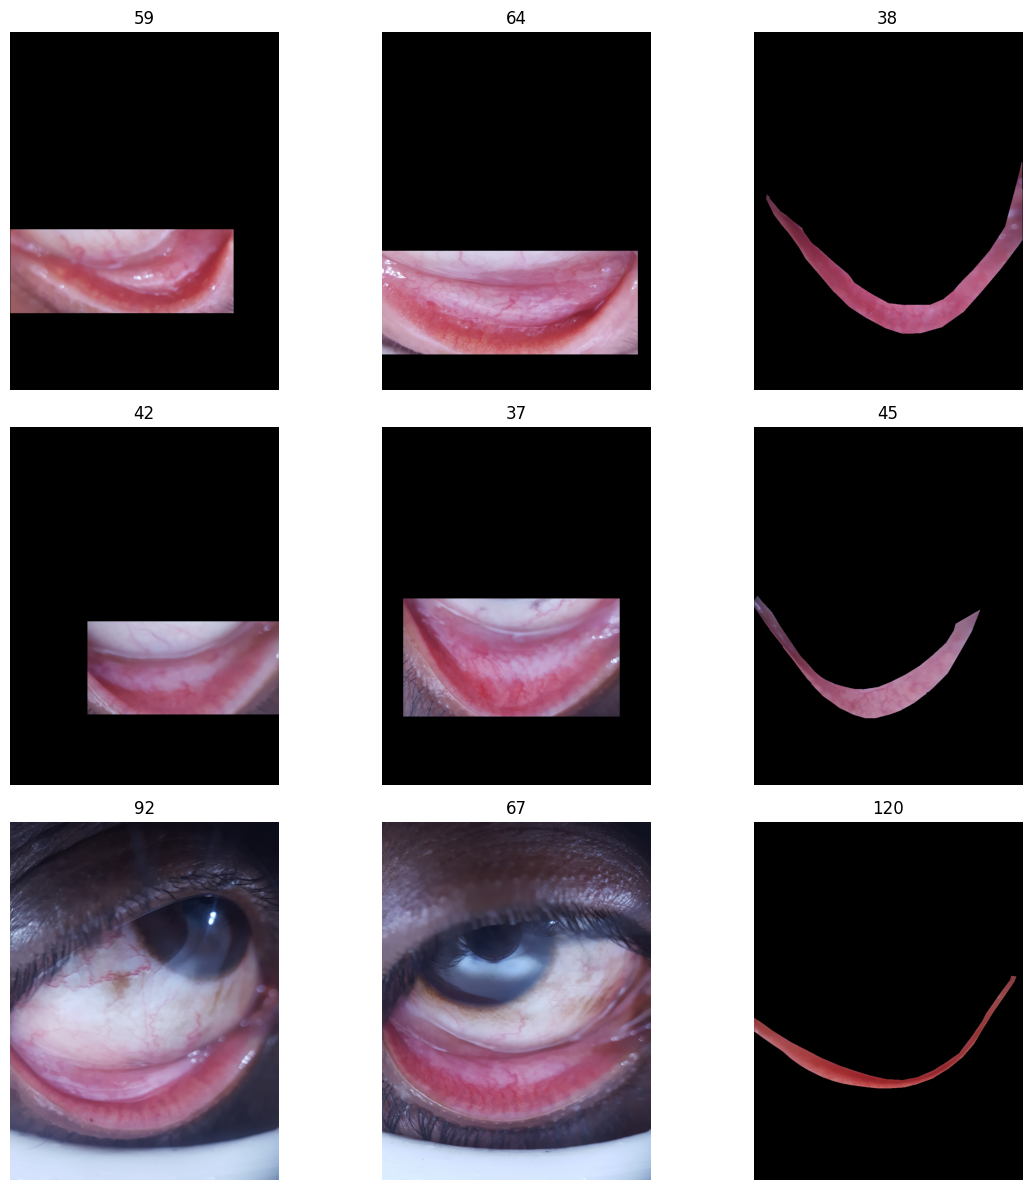

In [67]:
import cv2
import matplotlib.pyplot as plt
import random

sample_images = random.sample(image_paths, 9)

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(sample_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(img_path.parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()